# Meteo Cluster

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path

## Подготовка данных

In [2]:
from src.data import load_data, dataset_to_dataframe, normalize_dataframe
from config import config

dataset_path = config.data_dir / "2025_1000.nc"

ds = load_data(file_path=dataset_path, pressure_level=0)

In [3]:
ds

<xarray.Dataset> Size: 11MB
Dimensions:  (time: 61, lat: 91, lon: 120)
Coordinates:
  * time     (time) datetime64[ns] 488B 2025-11-01T10:30:00 ... 2025-12-31T10...
  * lat      (lat) float64 728B -90.0 -88.0 -86.0 -84.0 ... 84.0 86.0 88.0 90.0
  * lon      (lon) float64 960B 0.0 3.0 6.0 9.0 12.0 ... 348.0 351.0 354.0 357.0
    lev      float64 8B 1e+03
Data variables:
    H        (time, lat, lon) float32 3MB ...
    T        (time, lat, lon) float32 3MB ...
    U        (time, lat, lon) float32 3MB ...
    V        (time, lat, lon) float32 3MB ...
Attributes: (12/35)
    CDI:                               Climate Data Interface version 1.7.1 (...
    Conventions:                       CF-1
    history:                           Wed Jan 28 15:09:34 2026: cdo sellevel...
    _NCProperties:                     version=1|netcdflibversion=4.5.0|hdf5l...
    History:                           Original file generated: Tue Nov 11 21...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    ...                                ...
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-11-01
    RangeEndingTime:                   21:00:00.000000
    frequency:                         day
    NCO:                               4.3.7
    CDO:                               Climate Data Operators version 1.7.1 (...

In [4]:
meteo_df = dataset_to_dataframe(ds, features=["H", "T", "U", "V"])

In [5]:
meteo_df.head(5)

H         T         U         V     lev
time                lon lat                                                  
2025-11-01 10:30:00 0.0 -90.0 -5.423445 -4.133301  4.570474  2.031699  1000.0
                        -88.0 -5.423445 -4.133301  4.570474  2.031699  1000.0
                        -86.0 -5.423445 -4.133301  4.570474  2.031699  1000.0
                        -84.0 -5.847328 -3.828979  4.720197  1.897010  1000.0
                        -82.0 -6.308565 -3.814880  4.802876  1.922760  1000.0

In [6]:
norm_meteo_df = normalize_dataframe(ds, features=["H", "T"])

In [7]:
norm_meteo_df.head(5)

,H,T
0,0.347682,-0.271171
1,0.347682,-0.271171
2,0.347682,-0.271171
3,0.345259,-0.263639
4,0.115625,-0.190686


In [8]:
meteo_array = meteo_df.to_numpy()
norm_meteo_array = norm_meteo_df.to_numpy()

## Исследование кластеризаторов

In [9]:
from src.evaluation import stratified_sample_by_cluster, calculate_metrics
from src.visualization import plot_cluster_map, plot_cluster_map_period, plot_parameter_change, plot_seasonal_similarity

### Кластеризатор KMeans

In [10]:
from src.models import KMeansClusterer

kmeans_clusterer = KMeansClusterer(random_state=42)

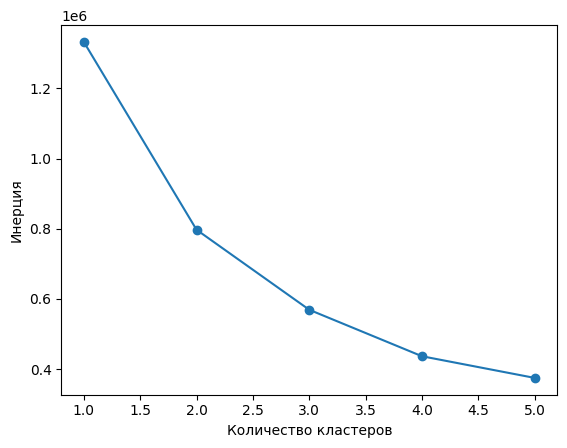

In [11]:
inertia_dict = kmeans_clusterer.elbow_method(norm_meteo_array, max_k=5)

In [12]:
kmeans_clusterer.update_params(n_clusters=3)
kmeans_clusterer.fit(norm_meteo_array)
labels = kmeans_clusterer.predict(norm_meteo_array)

#### Оценка метрик

In [13]:
sample_df, sample_labels = stratified_sample_by_cluster(norm_meteo_array, labels, sample_size=5000)

kmeans_results = calculate_metrics(sample_df, sample_labels)

for metric, score in kmeans_results.items():
    print(f"{metric}: {score:.4f}")

silhouette_score: 0.3458
calinski_harabasz_score: 10161.4112
davies_bouldin_score: 0.9491


In [14]:
clust_meteo_df = meteo_df.copy()
clust_meteo_df["cluster"] = labels
clust_meteo_array = clust_meteo_df.to_xarray()
clust_meteo_array.drop_vars("lev")

<xarray.Dataset> Size: 13MB
Dimensions:  (time: 61, lon: 120, lat: 91)
Coordinates:
  * time     (time) datetime64[ns] 488B 2025-11-01T10:30:00 ... 2025-12-31T10...
  * lon      (lon) float64 960B 0.0 3.0 6.0 9.0 12.0 ... 348.0 351.0 354.0 357.0
  * lat      (lat) float64 728B -90.0 -88.0 -86.0 -84.0 ... 84.0 86.0 88.0 90.0
Data variables:
    H        (time, lon, lat) float32 3MB -5.423 -5.423 -5.423 ... -98.64 -118.0
    T        (time, lon, lat) float32 3MB -4.133 -4.133 -4.133 ... 2.892 3.068
    U        (time, lon, lat) float32 3MB 4.57 4.57 4.57 ... 15.11 15.18 14.49
    V        (time, lon, lat) float32 3MB 2.032 2.032 2.032 ... -0.1188 -0.6411
    cluster  (time, lon, lat) int32 3MB 1 1 1 1 0 0 1 1 1 ... 1 1 1 1 1 0 0 0 0

#### Распределение кластеров в конкретный день

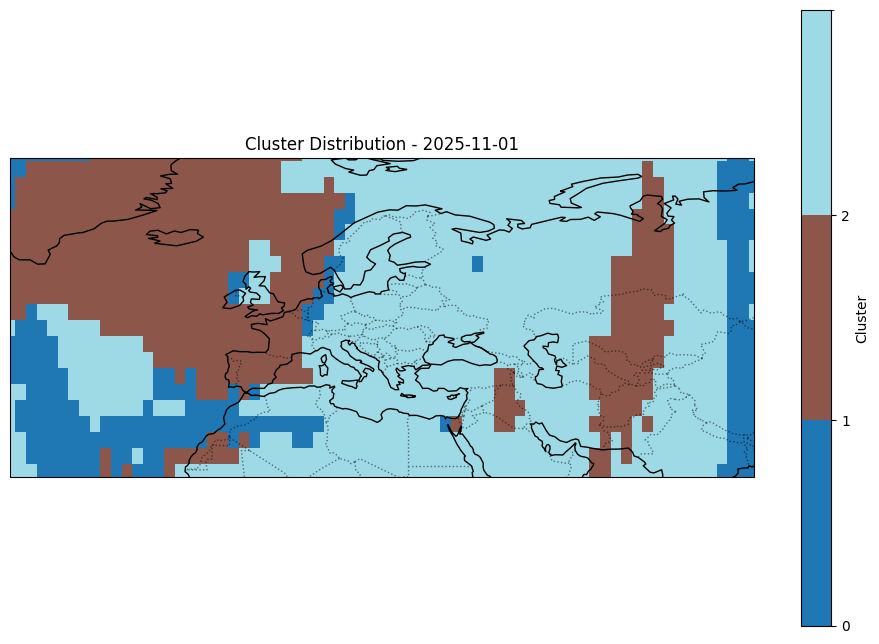

In [15]:
fig = plot_cluster_map(clust_meteo_array, 
                       time_idx=0,
                       output_path=config.output_dir / "cluster_map.png",
                       region=(-50, 90, 20, 80))
plt.show()

#### Преобладающие кластеры за период

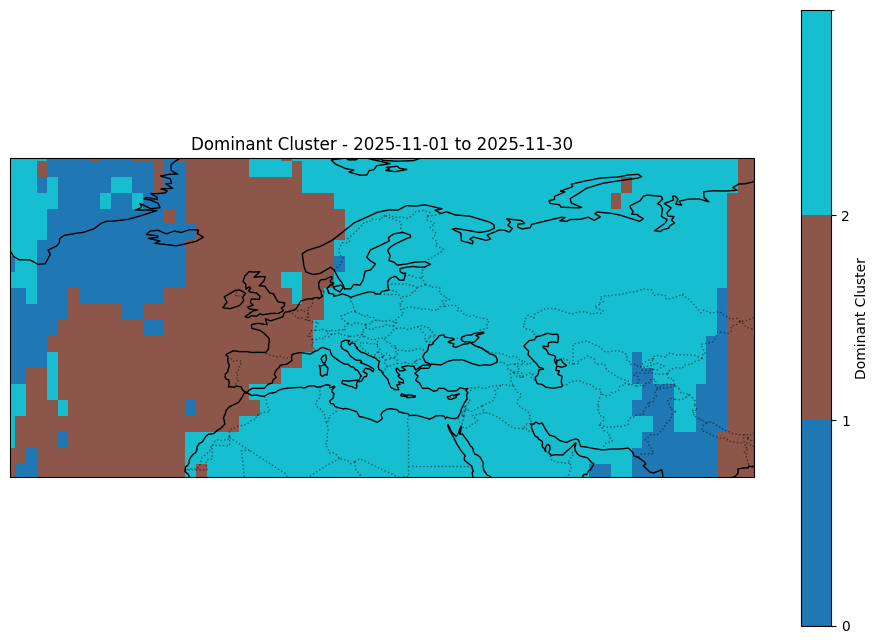

In [16]:
fig = plot_cluster_map_period(clust_meteo_array, 
                       time_range=(0, 30),
                       output_path=config.output_dir / "cluster_map_period.png",
                       region=(-50, 90, 20, 80))
plt.show()

#### Сравнение карты сходства кластеров между двумя периодами

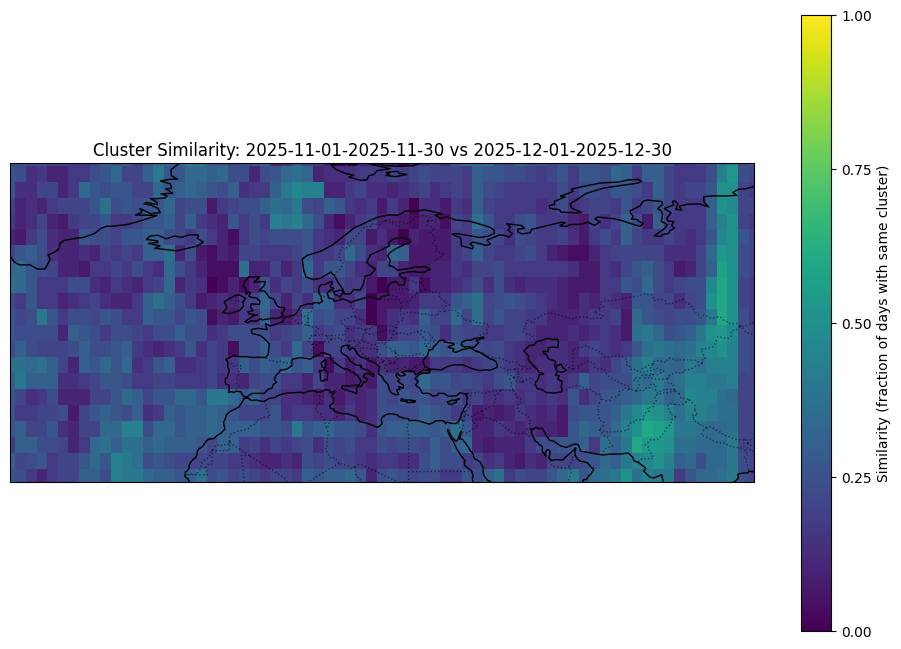

In [17]:
fig = plot_seasonal_similarity(clust_meteo_array,                                
                              period1=(0, 30),
                              period2=(30, 60),
                              output_path=config.output_dir / "seasonal_similarity.png",
                              region=(-50, 90, 20, 80))
plt.show()

#### Сравнение изменения температуры между двумя периодами

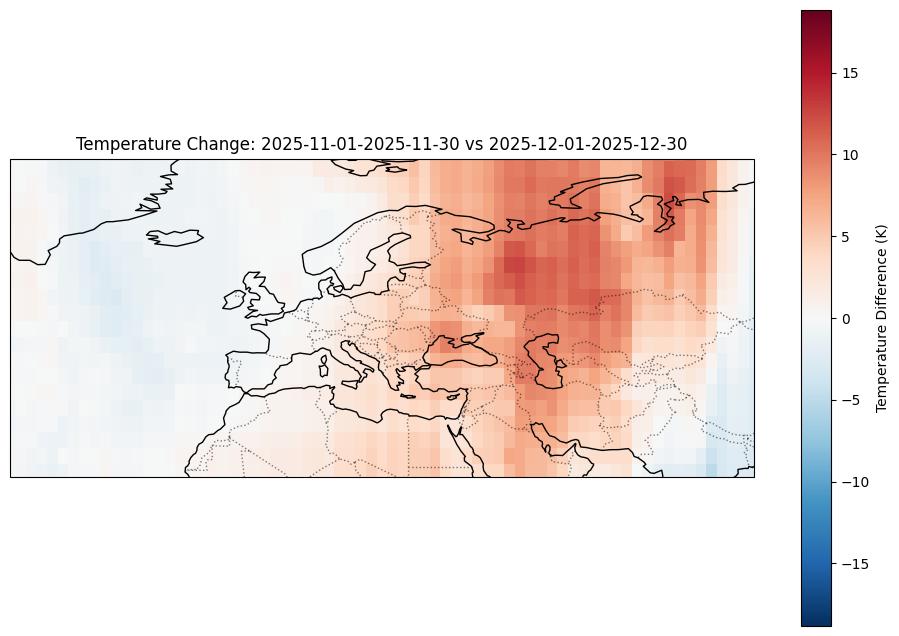

In [18]:
fig = plot_parameter_change(clust_meteo_array,
                              variable="T",
                              period1=(0, 30),
                              period2=(30, 60),
                              output_path=config.output_dir / "parameter_change.png",
                              region=(-50, 90, 20, 80))
plt.show()